# Importing libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix,accuracy_score, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import shap
sns.set(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10,6)

# Loading dataset

In [2]:
dataset = load_dataset(
    "patrickfleith/controlled-anomalies-time-series-dataset",
    data_files="data.csv"
)

README.md: 0.00B [00:00, ?B/s]

data.csv:   0%|          | 0.00/1.47G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [3]:
df = dataset["train"].to_pandas()

In [4]:
df = df.sample(200000, random_state=42)

In [5]:
print(df.shape)

(200000, 20)


In [6]:
df.head()

,timestamp,aimp,amud,arnd,asin1,asin2,adbr,adfl,bed1,bed2,bfo1,bfo2,bso1,bso2,bso3,ced1,cfo1,cso1,y,category
3577888,2023-02-11 09:51:28,0.0,-28.0,18.111633,0.643354,-0.648434,0.0,0.0,0.439277,0.002354,0.000002,33.676889,-28.652164,0.425140,0.095012,392.051913,-27.669444,6.508715,0.0,0.0
4993932,2023-02-27 19:12:12,0.0,-8.0,21.284518,-0.607036,-0.237765,0.0,1.0,0.745046,0.142396,0.036075,28.252682,-8.242469,1.432041,0.221170,324.839783,-6.074204,20.241118,0.0,0.0
4094900,2023-02-17 09:28:20,0.0,-1.0,30.620094,0.214902,0.828085,0.0,1.0,0.665658,0.008216,0.224906,43.631179,-0.169168,1.161748,0.309922,261.041273,2.620973,43.690832,0.0,0.0
4420497,2023-02-21 03:54:57,0.0,-1.0,20.933087,0.430770,-0.966664,0.0,1.0,0.773620,0.225936,6.617477,56.653925,-1.972327,0.778126,0.349377,165.198457,-5.135704,55.894110,0.0,0.0
634465,2023-01-08 08:14:25,0.0,8.0,21.102868,0.122620,0.942253,1.0,0.0,0.483250,0.001447,20.621696,52.123161,8.941197,-0.459285,0.321393,411.870330,-8.140406,61.332942,0.0,0.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 3577888 to 3967119
Data columns (total 20 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   timestamp  200000 non-null  object 
 1   aimp       200000 non-null  float64
 2   amud       200000 non-null  float64
 3   arnd       200000 non-null  float64
 4   asin1      200000 non-null  float64
 5   asin2      200000 non-null  float64
 6   adbr       200000 non-null  float64
 7   adfl       200000 non-null  float64
 8   bed1       200000 non-null  float64
 9   bed2       200000 non-null  float64
 10  bfo1       200000 non-null  float64
 11  bfo2       200000 non-null  float64
 12  bso1       200000 non-null  float64
 13  bso2       200000 non-null  float64
 14  bso3       200000 non-null  float64
 15  ced1       200000 non-null  float64
 16  cfo1       200000 non-null  float64
 17  cso1       200000 non-null  float64
 18  y          200000 non-null  float64
 19  category   200000 non

In [8]:
df.isnull().sum()

,0
timestamp,0
aimp,0
amud,0
arnd,0
asin1,0
asin2,0
adbr,0
adfl,0
bed1,0
bed2,0


In [9]:
df.describe()

,aimp,amud,arnd,asin1,asin2,adbr,adfl,bed1,bed2,bfo1,bfo2,bso1,bso2,bso3,ced1,cfo1,cso1,y,category
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.010185,-2.061140,20.351450,0.002312,-0.000591,0.503075,0.603730,1.006449,0.201100,10.277214,45.316127,-2.038827,0.604207,0.304464,383.240015,-9.274424,43.868032,0.038055,0.243950
std,0.100406,12.485366,10.038148,0.707640,0.707610,0.499992,0.489123,0.719087,0.322564,10.912493,15.011451,12.592202,0.696910,0.112026,152.786712,15.941680,18.139523,0.191330,1.408463
min,0.000000,-47.000000,10.000000,-1.000000,-1.000000,0.000000,0.000000,-7.392471,-2.611574,-111.692401,-171.763723,-88.758356,-4.012447,-1.456883,-807.543905,-153.603461,-203.031434,0.000000,0.000000
25%,0.000000,-7.000000,12.445370,-0.706461,-0.710389,0.000000,0.000000,0.451368,0.001062,0.801967,36.825645,-7.456650,0.014709,0.232780,281.134337,-18.499978,32.909636,0.000000,0.000000
50%,0.000000,0.000000,16.788586,0.009477,0.000083,1.000000,1.000000,0.895030,0.034905,8.452433,45.372078,-0.730284,0.703646,0.301849,367.670714,-7.385701,43.878576,0.000000,0.000000
75%,0.000000,5.000000,25.464694,0.709449,0.708388,1.000000,1.000000,1.414077,0.274389,15.196304,53.910127,4.787313,1.133878,0.372822,466.606417,1.292424,55.024234,0.000000,0.000000
max,1.000000,37.000000,50.000000,1.000000,1.000000,1.000000,1.000000,12.898708,4.191318,409.422236,1058.155986,129.025368,20.383733,6.695874,5743.495999,127.466662,293.173087,1.000000,13.000000


# EDA

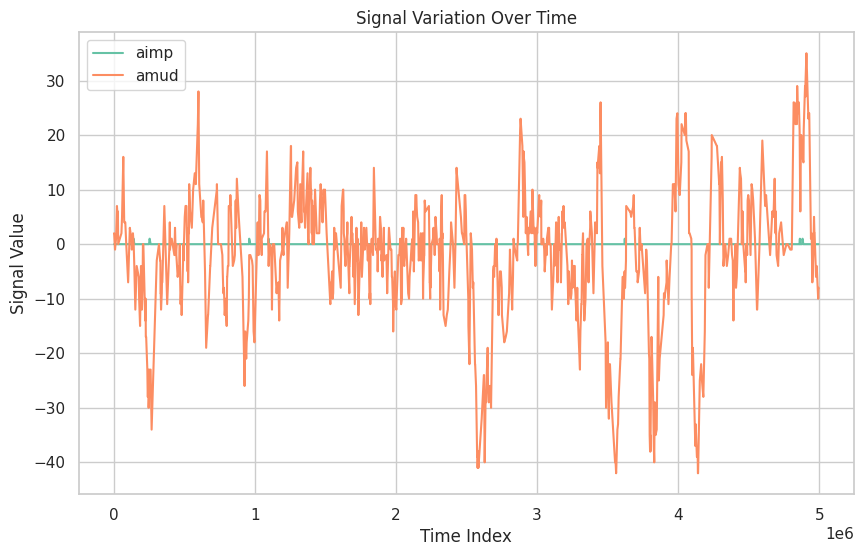

In [10]:
#Line Plot
plt.figure()
sns.lineplot(data=df.iloc[:1000], x=df.index[:1000], y="aimp", label="aimp")
sns.lineplot(data=df.iloc[:1000], x=df.index[:1000], y="amud", label="amud")

plt.title("Signal Variation Over Time")
plt.xlabel("Time Index")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

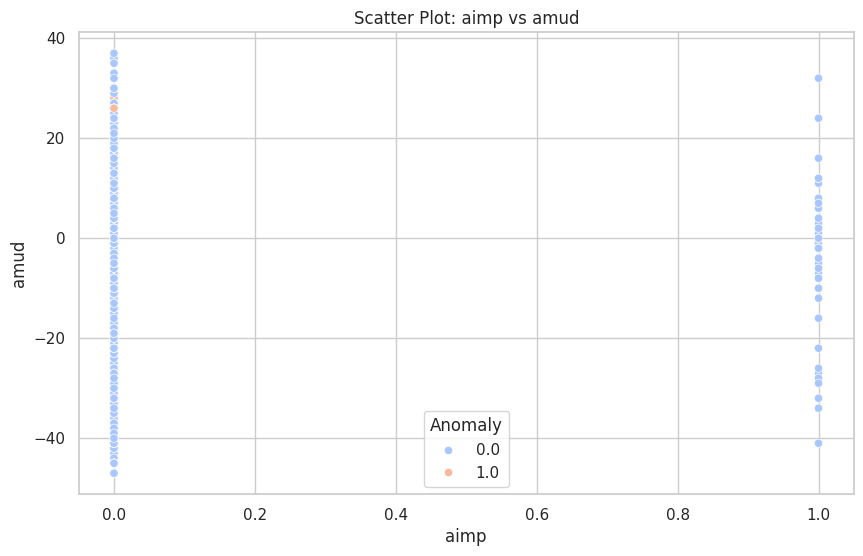

In [11]:
# Scatter Plot
plt.figure()
sns.scatterplot(data=df.sample(5000), x="aimp", y="amud", hue="y", palette="coolwarm")
plt.title("Scatter Plot: aimp vs amud")
plt.legend(title="Anomaly")
plt.show()

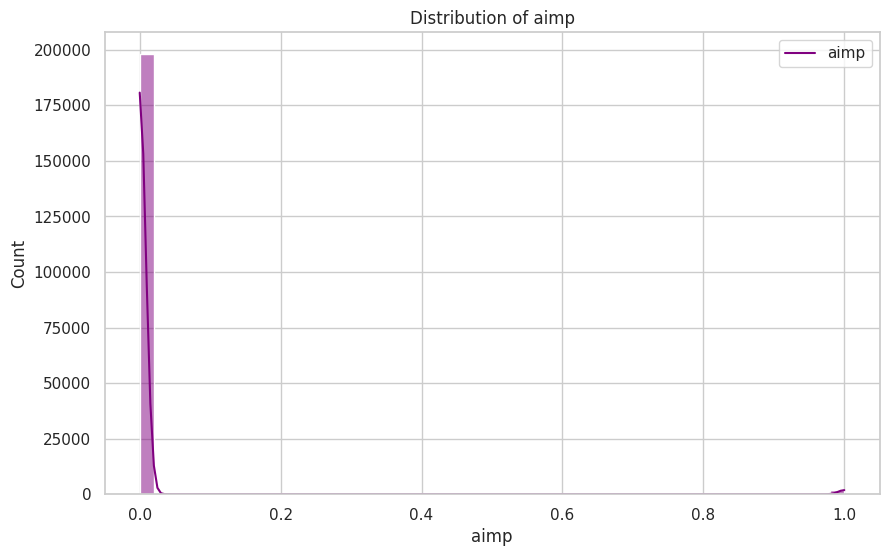

In [12]:
# Feature Distribution4
plt.figure()
sns.histplot(df["aimp"], bins=50, kde=True, color="purple")
plt.title("Distribution of aimp")
plt.legend(["aimp"])
plt.show()

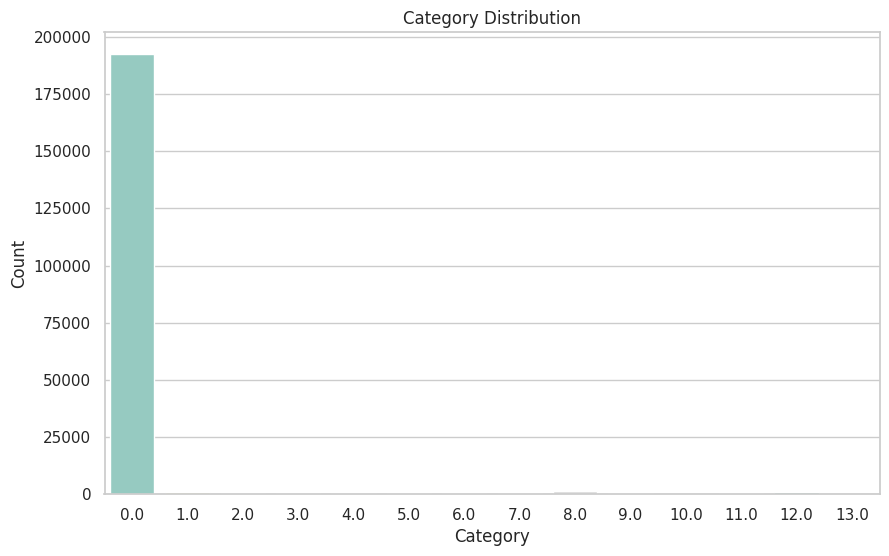

In [13]:
# Category plt.figure()
sns.countplot(x="category", data=df, palette="Set3")
plt.title("Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

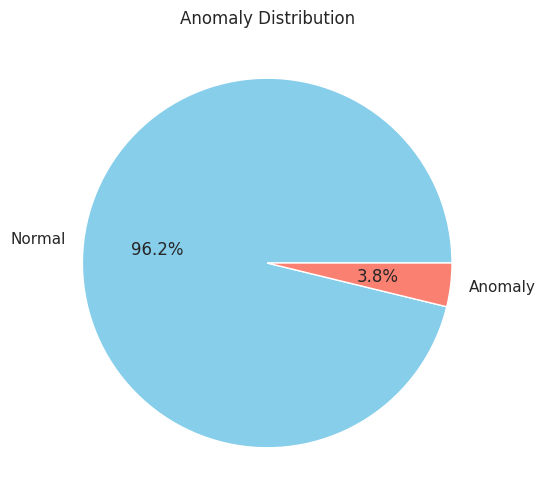

In [14]:
# Pie Chart
anomaly_counts = df["y"].value_counts()

plt.figure()
plt.pie(anomaly_counts, labels=["Normal", "Anomaly"], autopct="%1.1f%%",
        colors=["skyblue", "salmon"])
plt.title("Anomaly Distribution")
plt.show()

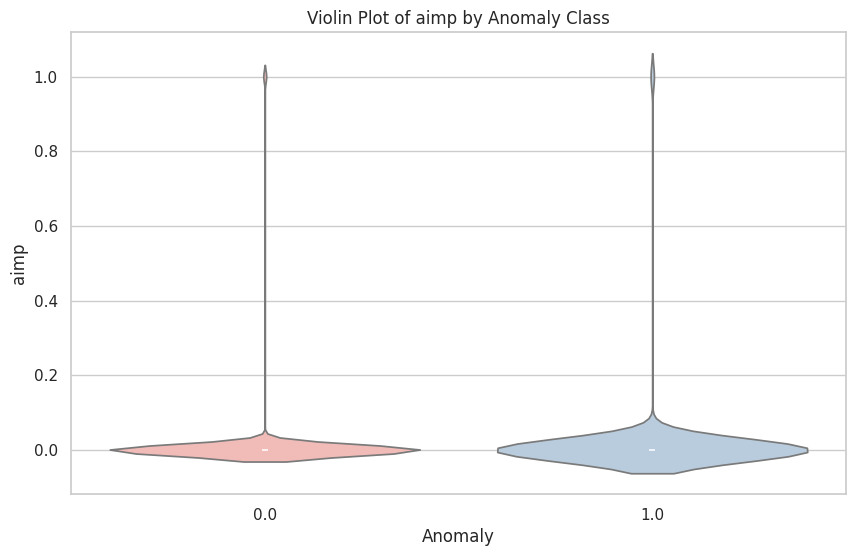

In [15]:
# Distribution by Anomaly
plt.figure()
sns.violinplot(x="y", y="aimp", data=df.sample(10000), palette="Pastel1")
plt.title("Violin Plot of aimp by Anomaly Class")
plt.xlabel("Anomaly")
plt.ylabel("aimp")
plt.show()

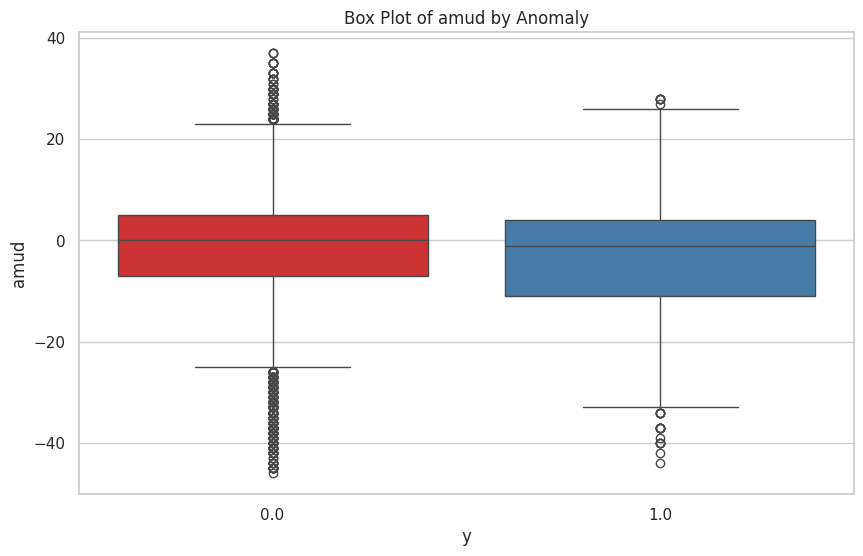

In [16]:
# Box Plot
plt.figure()
sns.boxplot(x="y", y="amud", data=df.sample(10000), palette="Set1")
plt.title("Box Plot of amud by Anomaly")
plt.show()

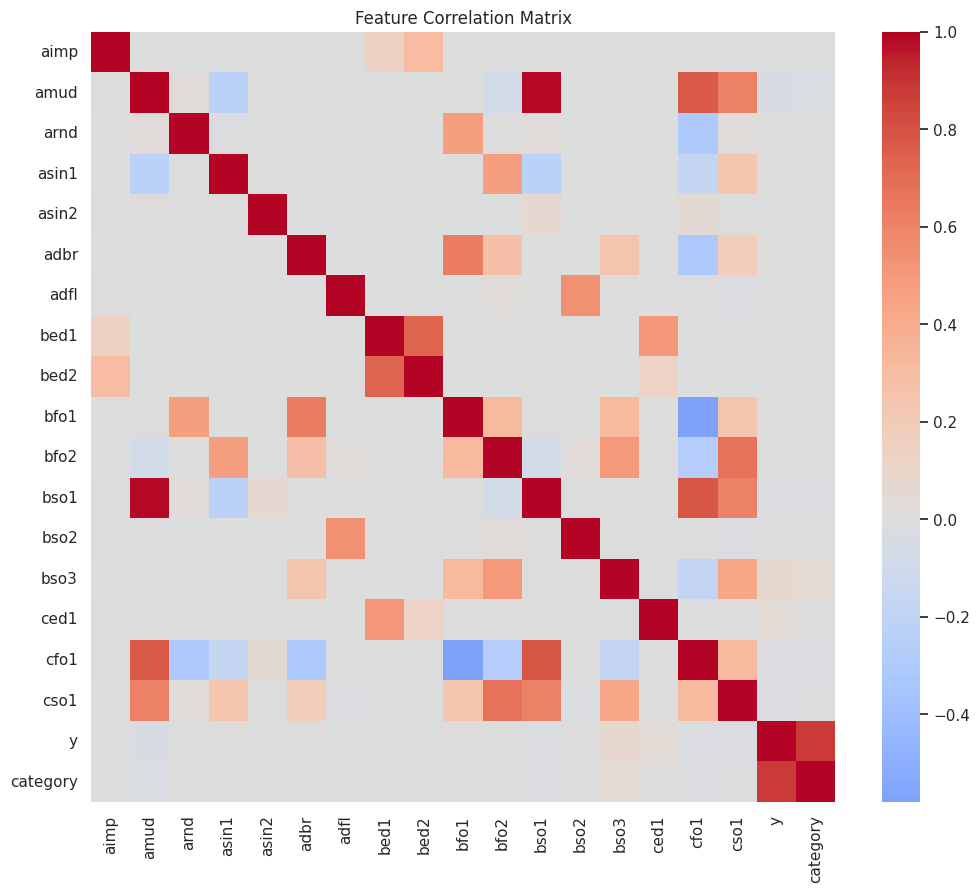

In [17]:
# Correlation Heatmap
plt.figure(figsize=(12,10))
corr = df.drop(columns=["timestamp"]).corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

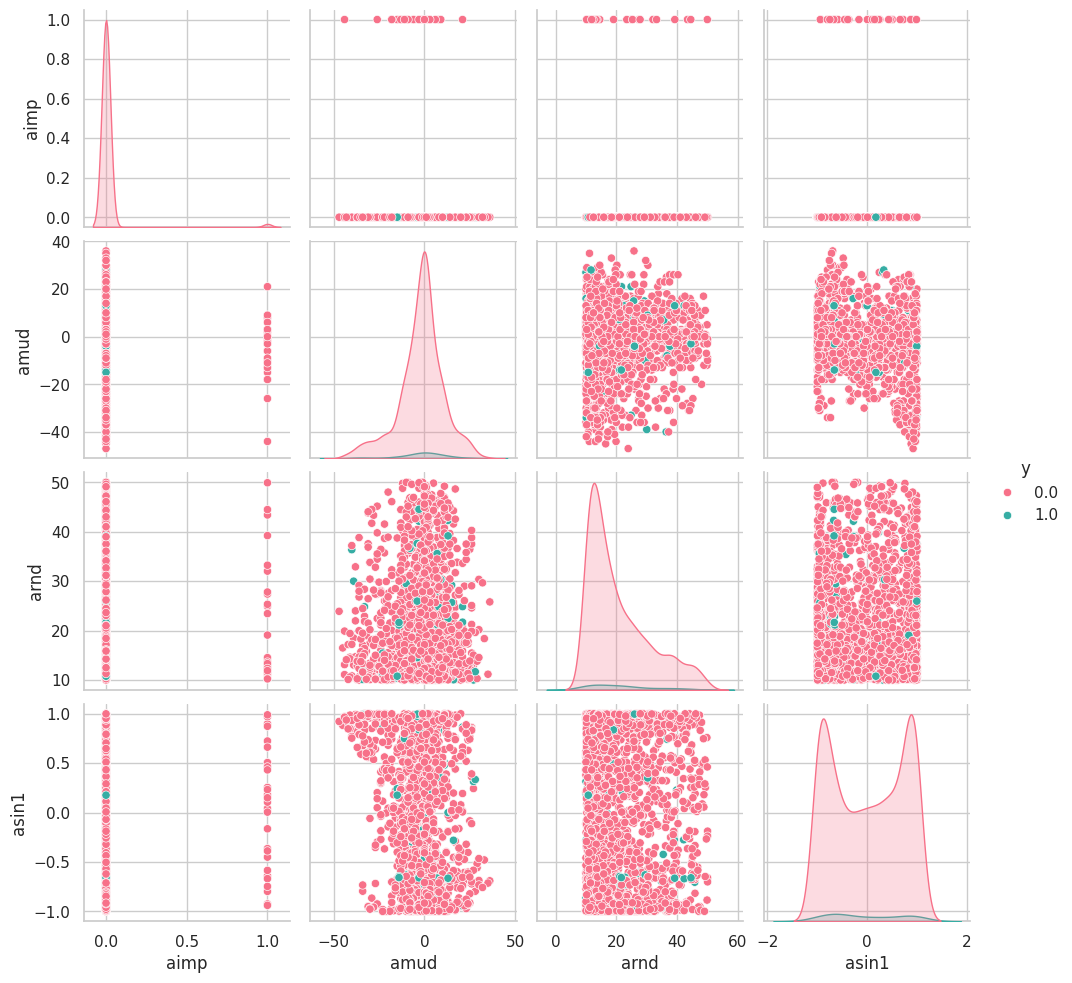

In [18]:
# Pair Plot
sns.pairplot(
    df.sample(2000)[["aimp","amud","arnd","asin1","y"]],
    hue="y",
    palette="husl"
)
plt.show()

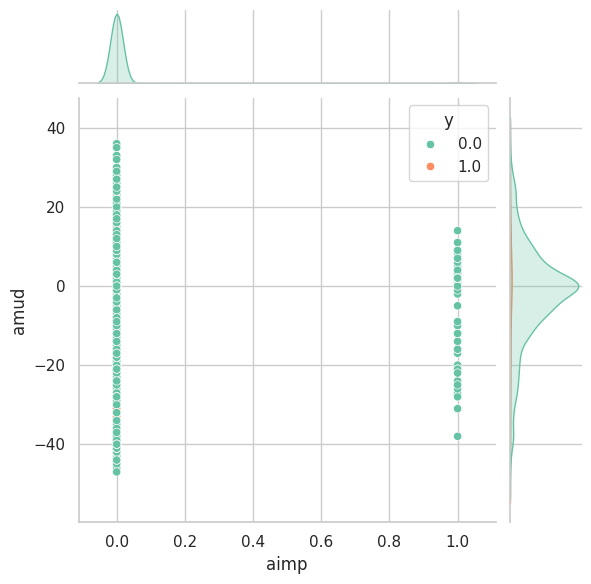

In [19]:
# Joint Plot
sns.jointplot(
    data=df.sample(5000),
    x="aimp",
    y="amud",
    hue="y",
    palette="Set2"
)
plt.show()

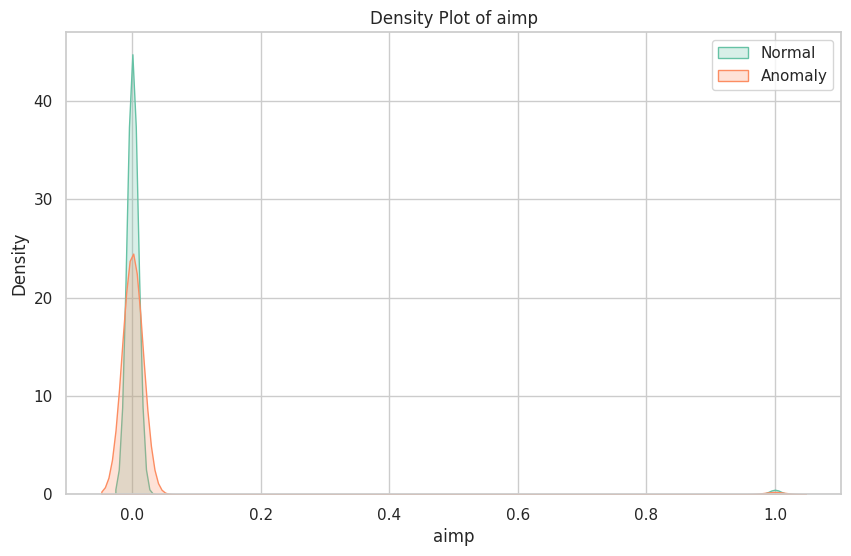

In [20]:
# KDE Plot
plt.figure()
sns.kdeplot(df[df["y"]==0]["aimp"], label="Normal", shade=True)
sns.kdeplot(df[df["y"]==1]["aimp"], label="Anomaly", shade=True)

plt.title("Density Plot of aimp")
plt.legend()
plt.show()

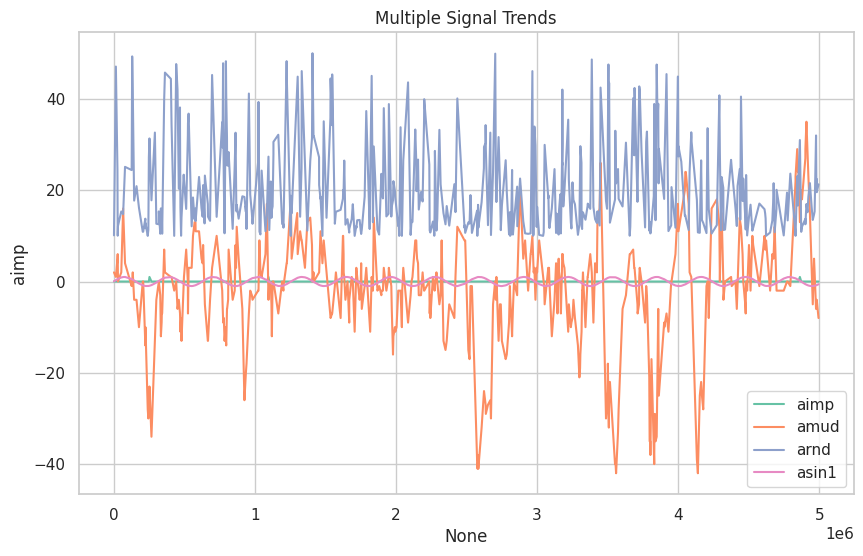

In [21]:
# Multi-Line Plot
signals = ["aimp", "amud", "arnd", "asin1"]

plt.figure()
for col in signals:
    sns.lineplot(data=df.iloc[:500], x=df.index[:500], y=col, label=col)

plt.title("Multiple Signal Trends")
plt.legend()
plt.show()

#Preprocessing

In [23]:
# Separating features and label
X = df.drop(columns=["timestamp", "y", "category"])
y = df["y"]

In [24]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modeling and Evaluation

In [26]:
# Evaluation
def evaluate_model(model_name, y_true, y_pred, anomaly_scores=None):

    print(f"\n{model_name}")

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))

    if anomaly_scores is not None:
        print("ROC-AUC:", roc_auc_score(y_true, anomaly_scores))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [27]:
# Statistical Threshold Method
mean_vector = np.mean(X_train_scaled, axis=0)

error = np.mean((X_test_scaled - mean_vector)**2, axis=1)

threshold = np.percentile(error, 95)
y_pred_stat = (error > threshold).astype(int)

In [28]:
evaluate_model(
    "Statistical Threshold Method",
    y_test,
    y_pred_stat,
    anomaly_scores=error
)


Statistical Threshold Method
Accuracy: 0.93195
Precision: 0.2
Recall: 0.2628120893561104
F1-Score: 0.2271436683702442
ROC-AUC: 0.6652057058869211

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.96     38478
         1.0       0.20      0.26      0.23      1522

    accuracy                           0.93     40000
   macro avg       0.59      0.61      0.60     40000
weighted avg       0.94      0.93      0.94     40000

Confusion Matrix:
[[36878  1600]
 [ 1122   400]]


In [29]:
#Isolation Forest
iso_model = IsolationForest(contamination=0.05, random_state=42)
iso_model.fit(X_train_scaled)

scores_iso = iso_model.decision_function(X_test_scaled)
y_pred_iso = (iso_model.predict(X_test_scaled) == -1).astype(int)

In [30]:
evaluate_model(
    "Isolation Forest",
    y_test,
    y_pred_iso,
    anomaly_scores=-scores_iso
)


Isolation Forest
Accuracy: 0.92225
Precision: 0.105759682224429
Recall: 0.13994743758212877
F1-Score: 0.12047511312217195
ROC-AUC: 0.6273666526442846

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.95      0.96     38478
         1.0       0.11      0.14      0.12      1522

    accuracy                           0.92     40000
   macro avg       0.54      0.55      0.54     40000
weighted avg       0.93      0.92      0.93     40000

Confusion Matrix:
[[36677  1801]
 [ 1309   213]]


In [31]:
# One-Class SVM
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
ocsvm.fit(X_train_scaled)

scores_svm = ocsvm.decision_function(X_test_scaled)
y_pred_svm = (ocsvm.predict(X_test_scaled) == -1).astype(int)

In [32]:
evaluate_model(
    "One-Class SVM",
    y_test,
    y_pred_svm,
    anomaly_scores=-scores_svm
)


One-Class SVM
Accuracy: 0.935475
Precision: 0.24158125915080528
Recall: 0.3252299605781866
F1-Score: 0.2772332679921591
ROC-AUC: 0.6895645404896796

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97     38478
         1.0       0.24      0.33      0.28      1522

    accuracy                           0.94     40000
   macro avg       0.61      0.64      0.62     40000
weighted avg       0.95      0.94      0.94     40000

Confusion Matrix:
[[36924  1554]
 [ 1027   495]]


In [33]:
# Prepare Sliding Windows for LSTM
def create_sequences(data, labels, window_size=10):
    sequences = []
    seq_labels = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
        seq_labels.append(labels.iloc[i+window_size])
    return np.array(sequences), np.array(seq_labels)

window_size = 10

X_train_seq, y_train_seq = create_sequences(
    pd.DataFrame(X_train_scaled), y_train.reset_index(drop=True), window_size
)

X_test_seq, y_test_seq = create_sequences(
    pd.DataFrame(X_test_scaled), y_test.reset_index(drop=True), window_size
)

In [34]:
# LSTM Autoencoder
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.LSTM(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        hidden = hidden.repeat(x.size(1), 1, 1).permute(1,0,2)
        output, _ = self.decoder(hidden)
        return output

In [35]:
# Train LSTM
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMAutoencoder(input_dim=X_train_seq.shape[2], hidden_dim=64).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_dataset = TensorDataset(torch.tensor(X_train_seq, dtype=torch.float32))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        inputs = batch[0].to(device)
        outputs = model(inputs)
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

Epoch 1, Loss: 0.8680128865480423
Epoch 2, Loss: 0.8362000619411468
Epoch 3, Loss: 0.8270713468313217
Epoch 4, Loss: 0.8216939394712448
Epoch 5, Loss: 0.8179015293598175
Epoch 6, Loss: 0.8145219901800156
Epoch 7, Loss: 0.8115798300504684
Epoch 8, Loss: 0.8091006965637207
Epoch 9, Loss: 0.8068525454759597
Epoch 10, Loss: 0.8046064129829407


In [36]:
# LSTM Evaluation
model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    reconstructed = model(X_test_tensor)

    reconstruction_error = torch.mean(
        (reconstructed - X_test_tensor)**2, dim=[1,2]
    ).cpu().numpy()

threshold_dl = np.percentile(reconstruction_error, 95)
y_pred_dl = (reconstruction_error > threshold_dl).astype(int)


In [37]:
evaluate_model(
    "LSTM Autoencoder",
    y_test_seq,
    y_pred_dl,
    anomaly_scores=reconstruction_error
)


LSTM Autoencoder
Accuracy: 0.9159039759939985
Precision: 0.0395
Recall: 0.05193951347797501
F1-Score: 0.0448736154501562
ROC-AUC: 0.49389066384369296

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96     38469
         1.0       0.04      0.05      0.04      1521

    accuracy                           0.92     39990
   macro avg       0.50      0.50      0.50     39990
weighted avg       0.93      0.92      0.92     39990

Confusion Matrix:
[[36548  1921]
 [ 1442    79]]


In [38]:
# Detection Delay
def detection_delay(y_true, y_pred):
    anomaly_indices = np.where(y_true == 1)[0]
    for idx in anomaly_indices:
        if y_pred[idx] == 1:
            return idx
    return -1

print("Detection Delay:", detection_delay(y_test_seq, y_pred_dl))

Detection Delay: 130


In [39]:
# GRU AUTOENCODER
class GRUAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GRUAutoencoder, self).__init__()

        self.encoder = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.decoder = nn.GRU(hidden_dim, input_dim, batch_first=True)

    def forward(self, x):
        _, hidden = self.encoder(x)
        hidden = hidden.repeat(x.size(1), 1, 1).permute(1,0,2)
        output, _ = self.decoder(hidden)
        return output

In [40]:
# Training GRU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gru_model = GRUAutoencoder(
    input_dim=X_train_seq.shape[2],
    hidden_dim=64
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    gru_model.train()
    total_loss = 0

    for batch in train_loader:
        inputs = batch[0].to(device)
        outputs = gru_model(inputs)
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"GRU Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

GRU Epoch 1, Loss: 0.8782703518867493
GRU Epoch 2, Loss: 0.8291973766565323
GRU Epoch 3, Loss: 0.8109442006826401
GRU Epoch 4, Loss: 0.8014394431829452
GRU Epoch 5, Loss: 0.79404448325634
GRU Epoch 6, Loss: 0.7894962881565094
GRU Epoch 7, Loss: 0.7856337238311768
GRU Epoch 8, Loss: 0.7819771909475327
GRU Epoch 9, Loss: 0.7775046442270279
GRU Epoch 10, Loss: 0.7719764005661011


In [41]:
# Evaluate GRU
gru_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    reconstructed = gru_model(X_test_tensor)

    reconstruction_error_gru = torch.mean(
        (reconstructed - X_test_tensor)**2, dim=[1,2]
    ).cpu().numpy()

threshold_gru = np.percentile(reconstruction_error_gru, 95)
y_pred_gru = (reconstruction_error_gru > threshold_gru).astype(int)

In [42]:
evaluate_model(
    "GRU Autoencoder",
    y_test_seq,
    y_pred_gru,
    anomaly_scores=reconstruction_error_gru
)

print("Detection Delay (GRU):", detection_delay(y_test_seq, y_pred_gru))


GRU Autoencoder
Accuracy: 0.9158039509877469
Precision: 0.0385
Recall: 0.05062458908612755
F1-Score: 0.0437375745526839
ROC-AUC: 0.49253237179679454

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96     38469
         1.0       0.04      0.05      0.04      1521

    accuracy                           0.92     39990
   macro avg       0.50      0.50      0.50     39990
weighted avg       0.93      0.92      0.92     39990

Confusion Matrix:
[[36546  1923]
 [ 1444    77]]
Detection Delay (GRU): 130


In [43]:
# TEMPORAL CONVOLUTIONAL NETWORK
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, dilation=1):
        super(TCNBlock, self).__init__()

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=(kernel_size-1)*dilation,
            dilation=dilation
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv(x)
        out = self.relu(out)
        return out[:, :, :-self.conv.padding[0]]

In [44]:
# Defining TCN Autoencoder
class TCNAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super(TCNAutoencoder, self).__init__()

        self.encoder = TCNBlock(input_dim, 64, dilation=1)
        self.decoder = TCNBlock(64, input_dim, dilation=1)

    def forward(self, x):
        # Convert to (batch, channels, seq_len)
        x = x.permute(0, 2, 1)

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        # Convert back
        decoded = decoded.permute(0, 2, 1)
        return decoded

In [45]:
# Training TCN
tcn_model = TCNAutoencoder(
    input_dim=X_train_seq.shape[2]
).to(device)

optimizer = torch.optim.Adam(tcn_model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    tcn_model.train()
    total_loss = 0

    for batch in train_loader:
        inputs = batch[0].to(device)
        outputs = tcn_model(inputs)
        loss = criterion(outputs, inputs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"TCN Epoch {epoch+1}, Loss: {total_loss/len(train_loader)}")

TCN Epoch 1, Loss: 0.4550329719543457
TCN Epoch 2, Loss: 0.4343354007720947
TCN Epoch 3, Loss: 0.4340030782699585
TCN Epoch 4, Loss: 0.43394806323051455
TCN Epoch 5, Loss: 0.4339336984872818
TCN Epoch 6, Loss: 0.43391852860450747
TCN Epoch 7, Loss: 0.4339113347887993
TCN Epoch 8, Loss: 0.4339105713486671
TCN Epoch 9, Loss: 0.4339046252608299
TCN Epoch 10, Loss: 0.43390422900915143


In [46]:
# Evaluating TCN
tcn_model.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32).to(device)
    reconstructed = tcn_model(X_test_tensor)

    reconstruction_error_tcn = torch.mean(
        (reconstructed - X_test_tensor)**2, dim=[1,2]
    ).cpu().numpy()

threshold_tcn = np.percentile(reconstruction_error_tcn, 95)
y_pred_tcn = (reconstruction_error_tcn > threshold_tcn).astype(int)

In [47]:
evaluate_model(
    "TCN Autoencoder",
    y_test_seq,
    y_pred_tcn,
    anomaly_scores=reconstruction_error_tcn
)

print("Detection Delay (TCN):", detection_delay(y_test_seq, y_pred_tcn))


TCN Autoencoder
Accuracy: 0.9156539134783696
Precision: 0.037
Recall: 0.04865220249835635
F1-Score: 0.042033513206475435
ROC-AUC: 0.5053642755698557

Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.96     38469
         1.0       0.04      0.05      0.04      1521

    accuracy                           0.92     39990
   macro avg       0.50      0.50      0.50     39990
weighted avg       0.93      0.92      0.92     39990

Confusion Matrix:
[[36543  1926]
 [ 1447    74]]
Detection Delay (TCN): 1933


In [48]:
# Plot Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

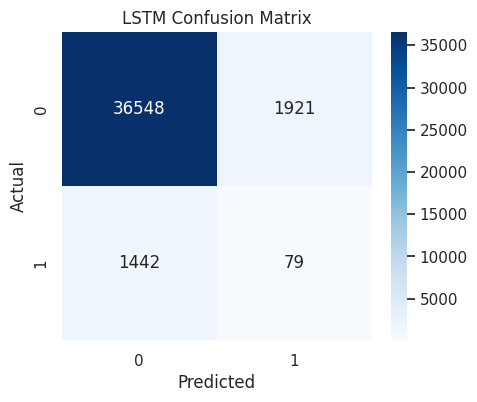

In [49]:
plot_confusion(y_test_seq, y_pred_dl, "LSTM Confusion Matrix")

In [51]:
model_results = {
    "Statistical": (y_test, y_pred_stat),
    "Isolation Forest": (y_test, y_pred_iso),
    "One-Class SVM": (y_test, y_pred_svm),
    "LSTM": (y_test_seq, y_pred_dl),
    "GRU": (y_test_seq, y_pred_gru),
    "TCN": (y_test_seq, y_pred_tcn)
}

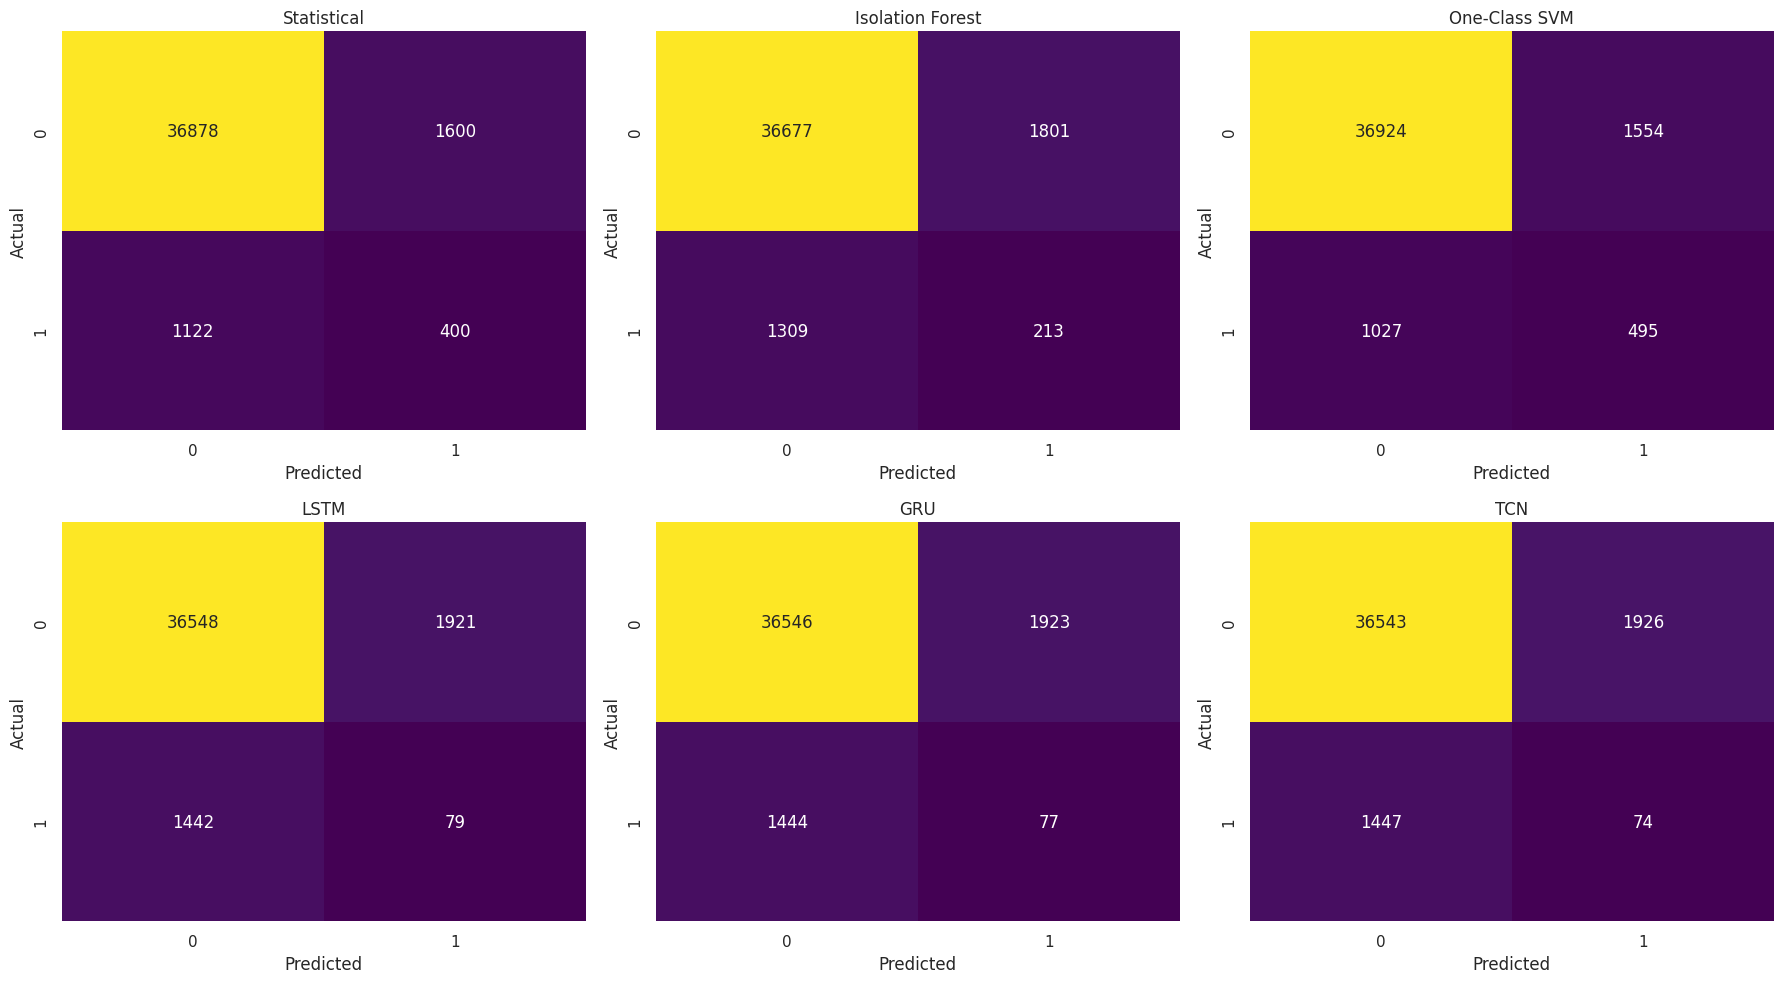

In [52]:
#Confusion Matrix for All Models
plt.figure(figsize=(18,10))

for i, (model_name, (y_true, y_pred)) in enumerate(model_results.items()):

    plt.subplot(2, 3, i+1)

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap="viridis",
        cbar=False
    )

    plt.title(f"{model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [53]:
# Model Accuracies
accuracy_data = []

for model_name, (y_true, y_pred) in model_results.items():
    acc = accuracy_score(y_true, y_pred)
    accuracy_data.append([model_name, acc])

accuracy_df = pd.DataFrame(
    accuracy_data,
    columns=["Model", "Accuracy"]
)

print(accuracy_df)

              Model  Accuracy
0       Statistical  0.931950
1  Isolation Forest  0.922250
2     One-Class SVM  0.935475
3              LSTM  0.915904
4               GRU  0.915804
5               TCN  0.915654


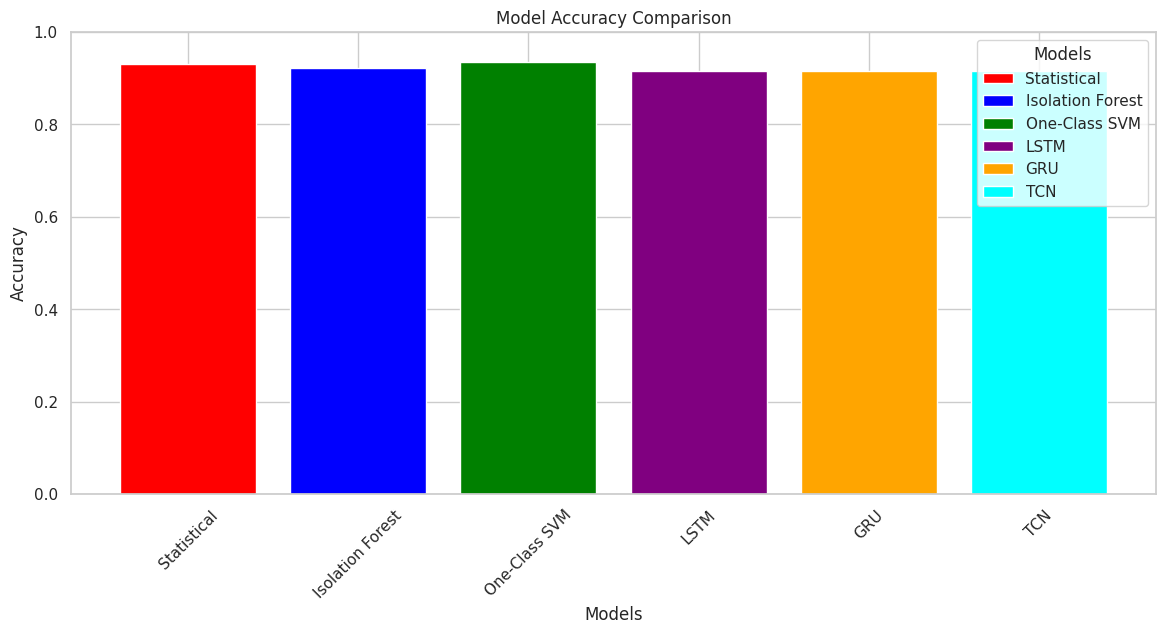

In [55]:
# Accuracy Comparison Plot
plt.figure(figsize=(14,6))

colors = ["red", "blue", "green", "purple", "orange", "cyan"]

bars = plt.bar(
    accuracy_df["Model"],
    accuracy_df["Accuracy"],
    color=colors
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.legend(bars, accuracy_df["Model"], title="Models")
plt.xticks(rotation=45)
plt.show()

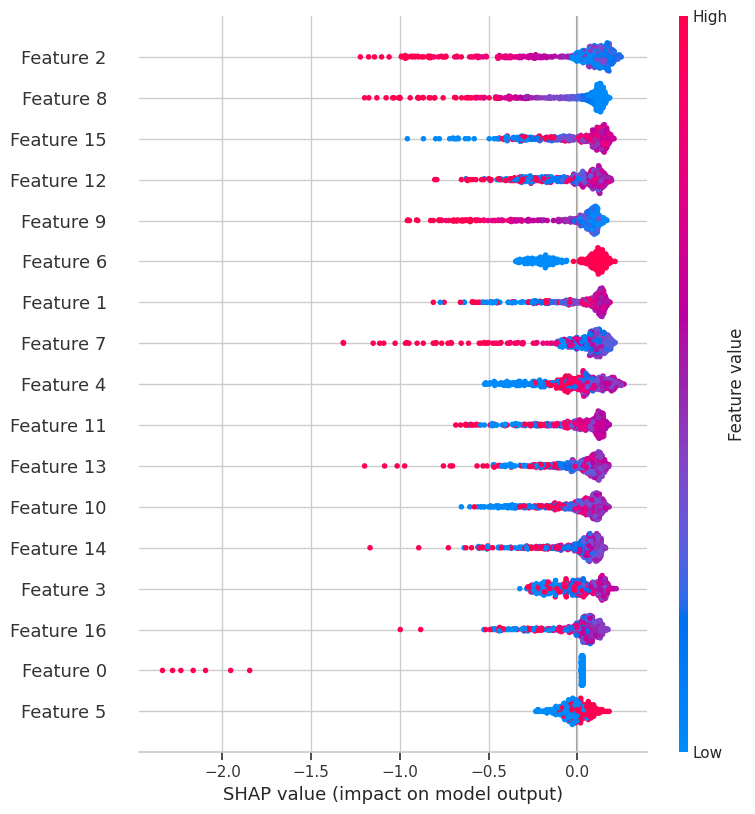

In [50]:
# SHAP
explainer = shap.TreeExplainer(iso_model)
shap_values = explainer.shap_values(X_test_scaled[:500])

shap.summary_plot(shap_values, X_test_scaled[:500])